<a href="https://colab.research.google.com/github/snehal1931/Breast-Cancer-Prediction-Model/blob/main/Breast_Cancer_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project: Breast Cancer Diagnosis Classification**
# 📌 Overview :
This project focuses on predicting whether a breast tumor is Malignant (M) or Benign (B) based on image-derived features from a Fine Needle Aspirate (FNA) of a breast mass. Accurate classification is vital for determining the appropriate medical treatment path for patients.

# 📊 Dataset Description
The dataset consists of 569 instances with 32 features (after excluding the ID). The features are computed from digitized images and represent characteristics of cell nuclei.

Key Statistics:
Total Samples: 569

Target Variable: diagnosis

Benign (B): 357 (62.7%)

Malignant (M): 212 (37.3%)

Features: 10 core real-valued features are provided in three forms: Mean, Standard Error (SE), and "Worst" (largest):

radius (mean of distances from center to points on the perimeter)

texture (standard deviation of gray-scale values)

perimeter

area

smoothness (local variation in radius lengths)

compactness (perimeter^2 / area - 1.0)

concavity (severity of concave portions of the contour)

concave points (number of concave portions of the contour)

symmetry

fractal dimension ("coastline approximation" - 1)

# 🎯 Project Objective
The goal is to build a Machine Learning pipeline that:

**Preprocesses the Data**: Handle the empty Unnamed: 32 column and encode the categorical target.

**Analyzes Correlations**: Identify which features (like radius_mean or area_worst) have the strongest relationship with malignancy.

**Trains Models**: Implement classification algorithms such as Logistic Regression, Random Forest, or Support Vector Machines (SVM).

**Evaluates Performance**: Use metrics like Accuracy, Precision, Recall, and the Confusion Matrix to ensure high sensitivity (minimizing false negatives).

# 🛠️ Tech Stack
Data Manipulation: pandas, numpy

Visualization: matplotlib, seaborn

Machine Learning: scikit-learn

In [ ]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#importing the dataset
df = pd.read_csv('data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Data Preprocessing Part 1

In [ ]:
# dropping unnecessary columns
df.drop(['Unnamed: 32','id'],axis=1,inplace=True)

In [ ]:
#checking for the missing values
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [ ]:
#checking the data types of the columns
df.dtypes

,0
diagnosis,object
radius_mean,float64
texture_mean,float64
perimeter_mean,float64
area_mean,float64
smoothness_mean,float64
compactness_mean,float64
concavity_mean,float64
concave points_mean,float64
symmetry_mean,float64


In [ ]:
# checking the data description
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Exploratory Data Analysis(EDA)

In [ ]:
# coorelation between the columns diagnosis and the other columns
from sklearn.preprocessing import LabelEncoder

# Encode the 'diagnosis' column (M=1, B=0)
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Calculate correlation with the new encoded diagnosis column, considering only numeric columns
correlation_with_diagnosis = df.corr(numeric_only=True)['diagnosis_encoded'].sort_values(ascending=False)


# df.drop('diagnosis_encoded', axis=1, inplace=True)

print(correlation_with_diagnosis)

diagnosis_encoded          1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

<Axes: xlabel='diagnosis'>

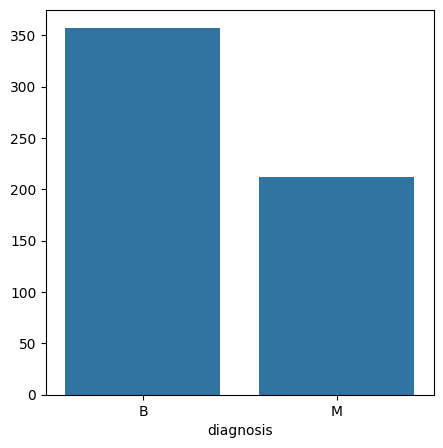

In [ ]:
# bar plot for the number of diagnosis
plt.figure(figsize=(5,5))
sns.barplot(x=df['diagnosis'].value_counts().index,y=df['diagnosis'].value_counts().values)


<Axes: >

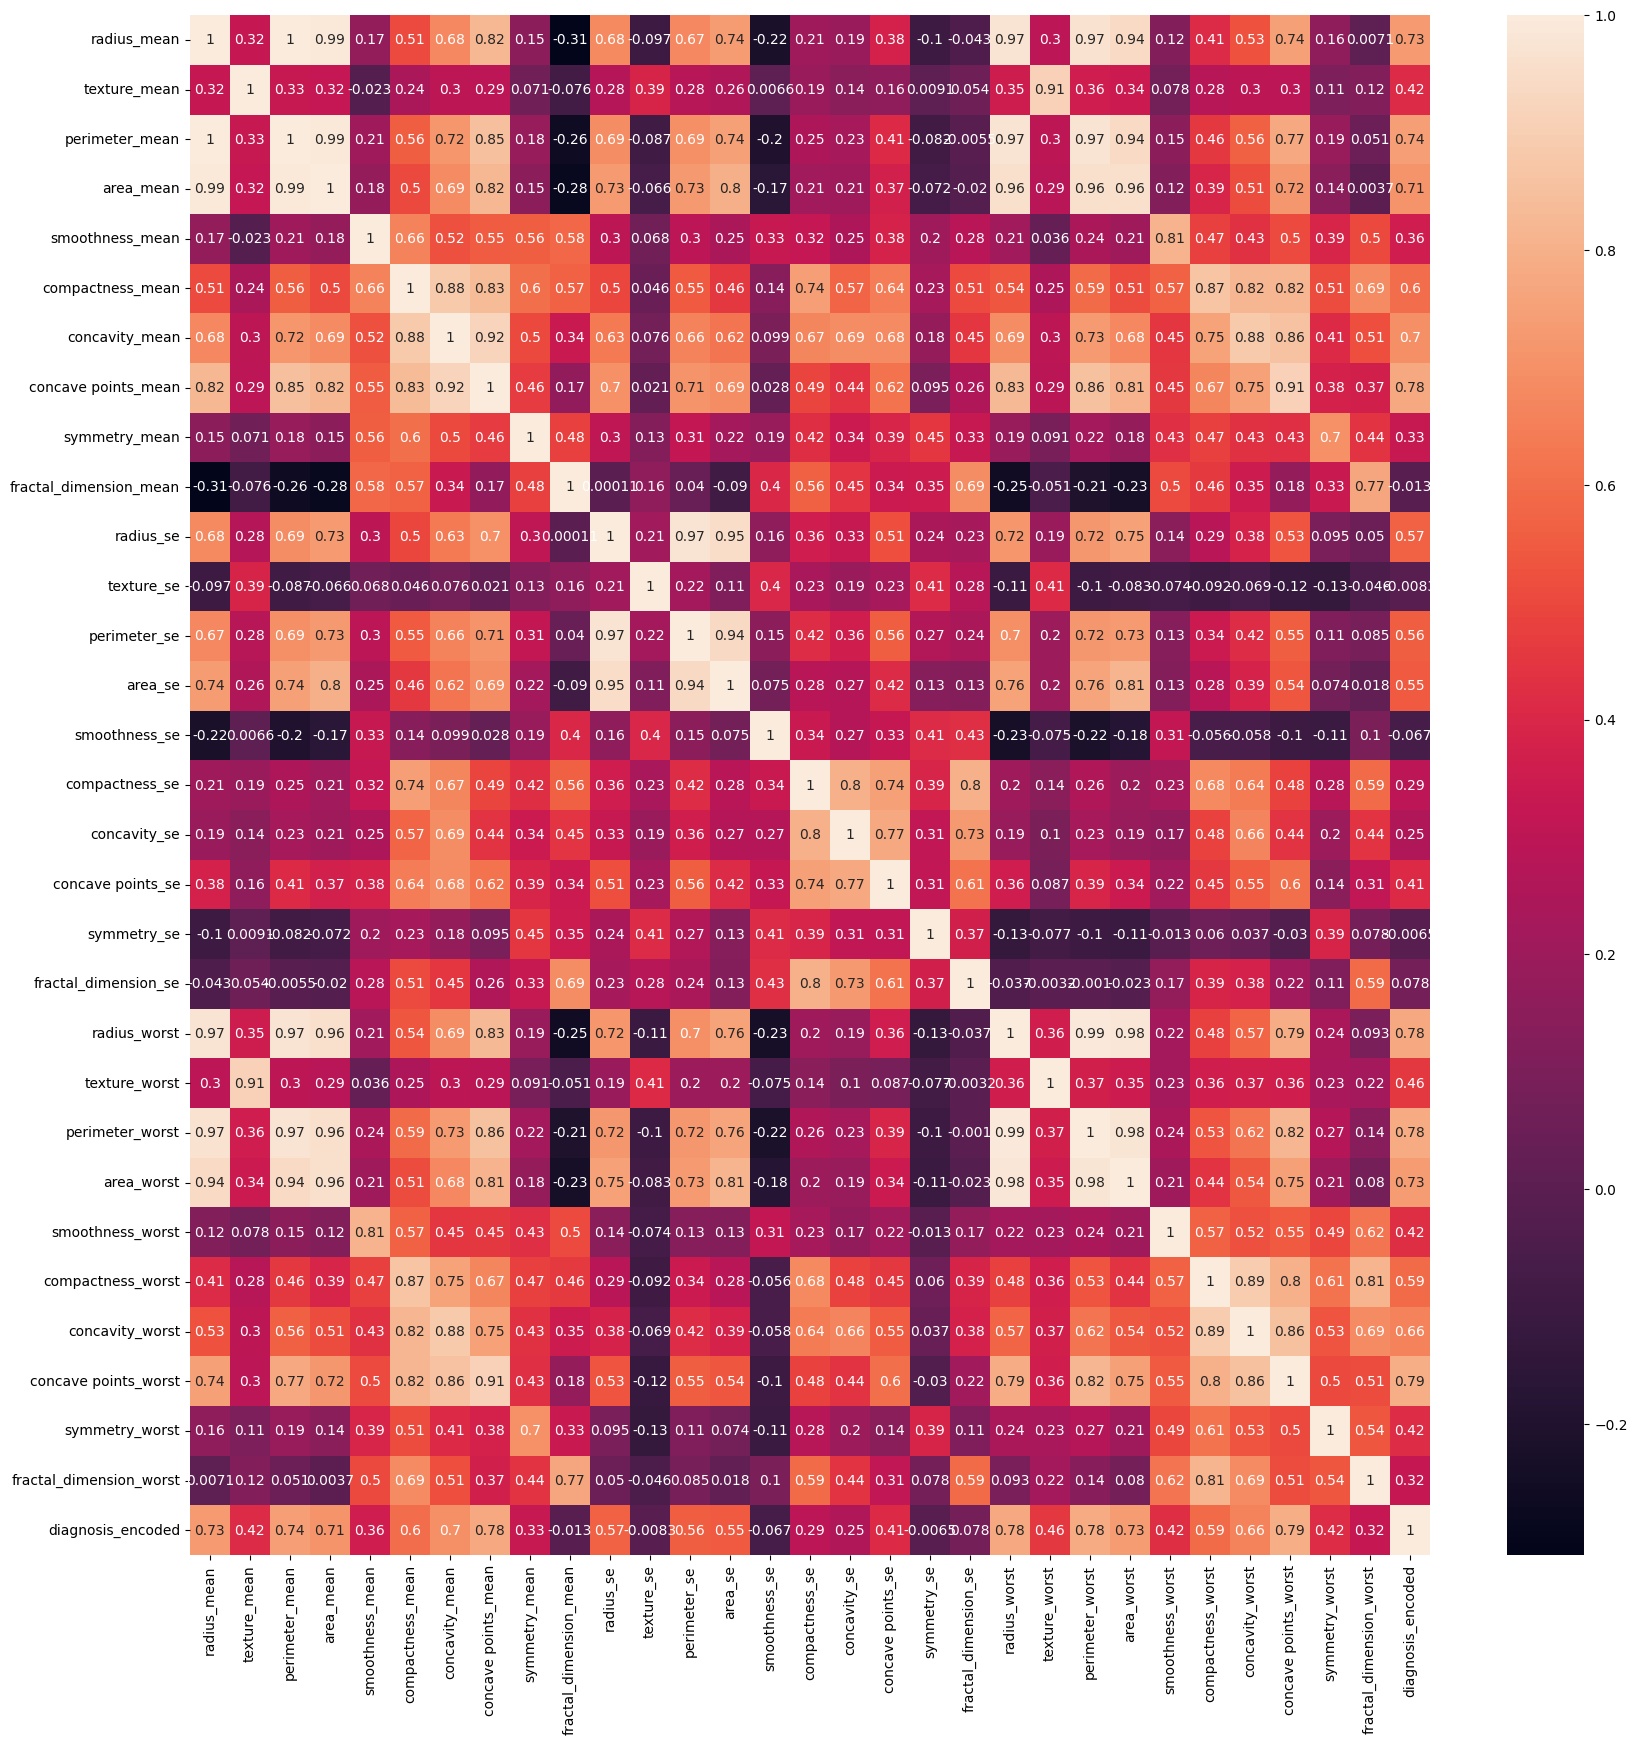

In [ ]:
# create a heatmap to check the correlation
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(['diagnosis'],axis=1),df['diagnosis'],test_size=0.3,random_state=42)

# Using Decision Tree Clasifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier()
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
#predicting the diagnosis
y_pred = dtree.predict(X_test)

# Model Evaluation

In [ ]:
# printing samples from predicted and actual values
print('Predicted values: ',y_pred[:10])
print('Actual values: ',y_test[:10])

Predicted values:  ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B']
Actual values:  204    B
70     M
131    M
431    B
540    B
567    M
369    M
29     M
81     B
477    B
Name: diagnosis, dtype: object


In [ ]:
# model evaluation
print(dtree.score(X_test,y_test))

1.0


# Using Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
yhat = logmodel.predict(X_test)

# Model Evaluation

In [ ]:
# printing samples from predicted and actual values
print('Predicted values: ',yhat[:10])
print('Actual values: ',y_test[:10])

Predicted values:  ['B' 'M' 'M' 'B' 'B' 'M' 'M' 'M' 'B' 'B']
Actual values:  204    B
70     M
131    M
431    B
540    B
567    M
369    M
29     M
81     B
477    B
Name: diagnosis, dtype: object


In [ ]:
# model evaluation
print(logmodel.score(X_test,y_test))

0.9941520467836257


# Conclusion

From both the models we can see that the accuracy is 93.5% and 97% respectively. But we can see the recall value for the logistic regression is 97% which is better than the decision tree classifier. So we can say that the logistic regression is better than the decision tree classifier.